# Dollar-Neutral Pair Trade: TXN / KVUE

A classic **dollar-neutral** pair trade: long TXN (Texas Instruments), short KVUE (Kenvue),
with BIL as collateral.

The strategy uses a **parent/child portfolio tree** with controlled book sizes via a hedge ratio:
- Long leg: TXN (equal weight)
- Short leg: KVUE (equal weight, negative)
- Parent controls the 1:1.135 hedge ratio between legs

This notebook demonstrates:
- Parent/child portfolio tree for long/short strategies
- `Weigh.Equally(short=True)` for short positions
- `Weigh.Ratio` for controlling book sizes
- Dollar-neutral construction

**Requires network**: KVUE (listed Sept 2023) and TXN are fetched live via YFinance.

In [1]:
import tiportfolio as ti

# Hedge ratio derived from OLS regression of TXN returns on KVUE returns
RATIO = 1.135
LONG_NAME = "long_txn"
SHORT_NAME = "short_kvue"

START = "2023-09-01"
END = "2024-12-31"

## 1. Load Data

KVUE was listed in September 2023, so the date range starts there.
Data is fetched live from YFinance.

In [2]:
data = ti.fetch_data(["TXN", "KVUE", "BIL"], start=START, end=END)

for ticker, df in data.items():
    print(f"{ticker}: {df.shape[0]} rows, {df.index[0].date()} \u2192 {df.index[-1].date()}")

Loading bar data...


[*********************100%***********************]  3 of 3 completed

Loaded bar data: 0:00:01 

BIL: 334 rows, 2023-09-01 → 2024-12-30
KVUE: 334 rows, 2023-09-01 → 2024-12-30
TXN: 334 rows, 2023-09-01 → 2024-12-30


## 2. Dollar-Neutral Strategy

The parent/child tree architecture:

```
dollar_neutral (parent)
├── long_txn (child)  — holds TXN with positive weight
└── short_kvue (child) — holds KVUE with negative weight
```

The parent allocates capital to each child based on the hedge ratio.
`Weigh.Equally(short=True)` makes weights negative for the short leg.

In [3]:
long = ti.Portfolio(
    LONG_NAME,
    [
        ti.Select.All(),
        ti.Weigh.Equally(),
        ti.Action.Rebalance(),
    ],
    ["TXN"],
)

short = ti.Portfolio(
    SHORT_NAME,
    [
        ti.Select.All(),
        ti.Weigh.Equally(short=True),
        ti.Action.Rebalance(),
    ],
    ["KVUE"],
)

# Parent allocates between long and short legs
# With RATIO=1.135: long gets ~46.8%, short gets ~53.2%
long_book = 1.0 / (1.0 + RATIO)
short_book = RATIO / (1.0 + RATIO)

dollar_neutral = ti.Portfolio(
    "dollar_neutral",
    [
        ti.Signal.Monthly(),
        ti.Select.All(),
        ti.Weigh.Ratio(weights={LONG_NAME: long_book, SHORT_NAME: short_book}),
        ti.Action.Rebalance(),
    ],
    [long, short],
)

print(f"Long book size:  {long_book:.3f}")
print(f"Short book size: {short_book:.3f}")

Long book size:  0.468
Short book size: 0.532


In [4]:
result = ti.run(ti.Backtest(dollar_neutral, data))

## 3. Results

In [5]:
result.summary()

,value
sharpe,-0.326
calmar,0.147
sortino,-0.435
max_drawdown,-0.190
cagr,-0.028
risk_free_rate,0.040
total_return,-0.037
kelly,-1.956
final_value,9631.559
total_fee,2.567


In [6]:
result[0].plot_interactive()

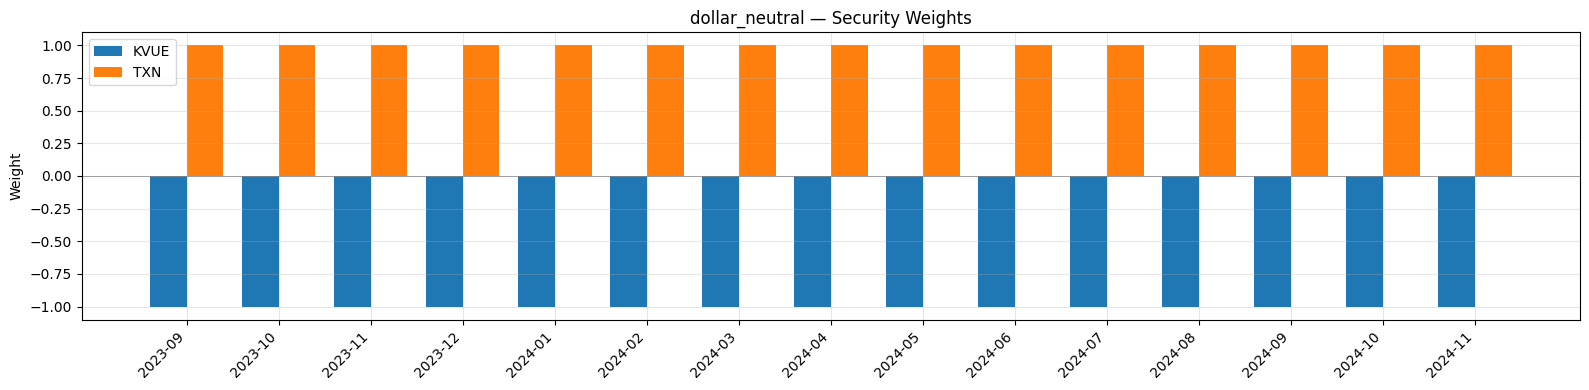

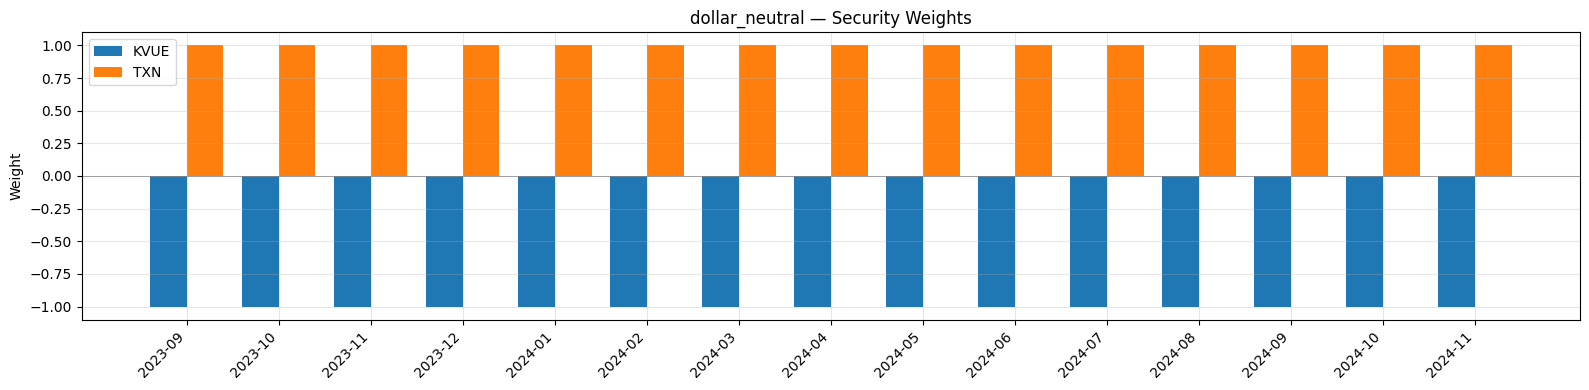

In [7]:
result[0].plot_security_weights()

In [8]:
print(f"Total trades: {len(result[0].trades)}")
result[0].trades.sample(3)

Total trades: 30


,date,portfolio,ticker,qty_before,qty_after,delta,price,fee,equity_before,equity_after
26,2024-10-31 04:00:00+00:00,long_txn,TXN,23.152162,23.307338,0.155176,195.495392,0.000543,4556.477128,4556.476585
24,2024-09-30 04:00:00+00:00,long_txn,TXN,23.455684,23.152162,-0.303522,197.476608,0.001062,4572.010383,4572.009318
10,2024-02-29 05:00:00+00:00,long_txn,TXN,30.298505,30.684300,0.385796,157.792084,0.001350,4841.739644,4841.738293
23,2024-08-30 04:00:00+00:00,short_kvue,KVUE,-345.984468,-264.082898,81.901571,20.656433,0.286655,5455.010711,5452.738832
13,2024-03-28 04:00:00+00:00,short_kvue,KVUE,-313.611126,-263.032089,50.579037,19.791649,0.177027,5205.838748,5203.937588
5,2023-11-30 05:00:00+00:00,short_kvue,KVUE,-313.147926,-274.488377,38.659549,18.658491,0.135308,5121.538950,5119.780623


## 4. Baseline Comparisons

Compare the dollar-neutral pair against:
1. **Long TXN Only** \u2014 100% TXN buy-and-hold
2. **50/50 TXN + BIL** \u2014 half in TXN, half in BIL

In [9]:
txn_only = ti.Portfolio(
    "txn_only",
    [ti.Signal.Once(), ti.Select.All(), ti.Weigh.Equally(), ti.Action.Rebalance()],
    ["TXN"],
)

txn_bil_5050 = ti.Portfolio(
    "txn_bil_5050",
    [
        ti.Signal.Monthly(),
        ti.Select.All(),
        ti.Weigh.Ratio(weights={"TXN": 0.5, "BIL": 0.5}),
        ti.Action.Rebalance(),
    ],
    ["TXN", "BIL"],
)

comparison = ti.run(
    ti.Backtest(dollar_neutral, data),
    ti.Backtest(txn_only, data),
    ti.Backtest(txn_bil_5050, data),
)

In [10]:
comparison.summary()

,dollar_neutral,txn_only,txn_bil_5050
sharpe,-0.326,0.379,0.585
calmar,0.147,0.668,1.360
sortino,-0.435,0.620,0.923
max_drawdown,-0.190,-0.165,-0.083
cagr,-0.028,0.110,0.112
risk_free_rate,0.040,0.040,0.040
total_return,-0.037,0.149,0.151
kelly,-1.956,1.459,4.572
final_value,9631.559,11486.969,11514.611
total_fee,2.567,0.222,0.452


In [11]:
comparison.plot_interactive()